In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import scipy.stats as stats
from numpy.ma.core import around
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.preprocessing import StandardScaler




In [45]:
data=pd.read_csv("../bank_projet.csv", sep=",")
print(data.head())
print(data.info())
print(data.describe())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 

In [46]:
data.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [47]:
zscore=np.abs(stats.zscore(data['balance']))
threeshold=5
aoutlaiers=data[zscore>threeshold]
print(aoutlaiers.count())
data_filter=data[zscore<=threeshold]

age          74
job          74
marital      74
education    74
default      74
balance      74
housing      74
loan         74
contact      74
day          74
month        74
duration     74
campaign     74
pdays        74
previous     74
poutcome     74
deposit      74
dtype: int64


In [48]:
age_deposit=data_filter.loc[data_filter["deposit"]=="yes"].groupby("age")["balance"].mean().reset_index()
print(age_deposit.head())
age_deposit.sort_values(by="balance",ascending=False,inplace=True)
print(age_deposit.head())
fig=px.bar(age_deposit,x="age",y="balance",color="age")
fig.show()



   age      balance
0   18   270.142857
1   19   324.181818
2   20  1126.666667
3   21  1171.454545
4   22   813.650000
    age      balance
67   85  5270.000000
61   79  3553.600000
69   87  3055.333333
57   75  2912.733333
53   71  2908.800000


In [49]:
fig=px.bar(data_filter,x="marital",y="deposit",color="marital")
fig.show()

In [50]:
duration_deposit=data_filter.groupby("deposit")["duration"].mean().reset_index()
fig=px.bar(duration_deposit,x="deposit",y="duration",color="deposit")
fig.show()

In [51]:
col_categ=[col for col in data_filter.columns if data_filter[col].dtype == 'object']
print(col_categ)

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


In [52]:
data_filter = data_filter.copy()
for col in col_categ:
    le = LabelEncoder()
    data_filter[col] = le.fit_transform(data_filter[col])
print(data_filter)

       age  job  marital  education  default  balance  housing  loan  contact  \
0       59    0        1          1        0     2343        1     0        2   
1       56    0        1          1        0       45        0     0        2   
2       41    9        1          1        0     1270        1     0        2   
3       55    7        1          1        0     2476        1     0        2   
4       54    0        1          2        0      184        0     0        2   
...    ...  ...      ...        ...      ...      ...      ...   ...      ...   
11157   33    1        2          0        0        1        1     0        0   
11158   39    7        1          1        0      733        0     0        2   
11159   32    9        2          1        0       29        0     0        0   
11160   43    9        1          1        0        0        0     1        0   
11161   34    9        1          1        0        0        0     0        0   

       day  month  duration

In [53]:
loen_deposit=data_filter.groupby("deposit")["loan"].mean().reset_index()
print(loen_deposit.head())
dic={1:"Yes",0:'No'}
loen_deposit_coder=loen_deposit.replace(dic)
fig=px.bar(loen_deposit_coder,x="deposit",y="loan",color="deposit",labels={"loan":"Moyen loan","deposit":"deposit"})
fig.show()

   deposit      loan
0        0  0.166838
1        1  0.092000


In [54]:
default_deposit=data_filter.groupby("deposit")["default"].mean().reset_index()
print(default_deposit.head())
dic={1:"Yes",0:'No'}
default_deposit_coder=default_deposit.replace(dic)
fig=px.bar(default_deposit_coder,x="deposit",y="default",color="deposit",labels={"default":"Moyen default","deposit":"deposit"})
fig.show()

   deposit   default
0        0  0.019870
1        1  0.009905


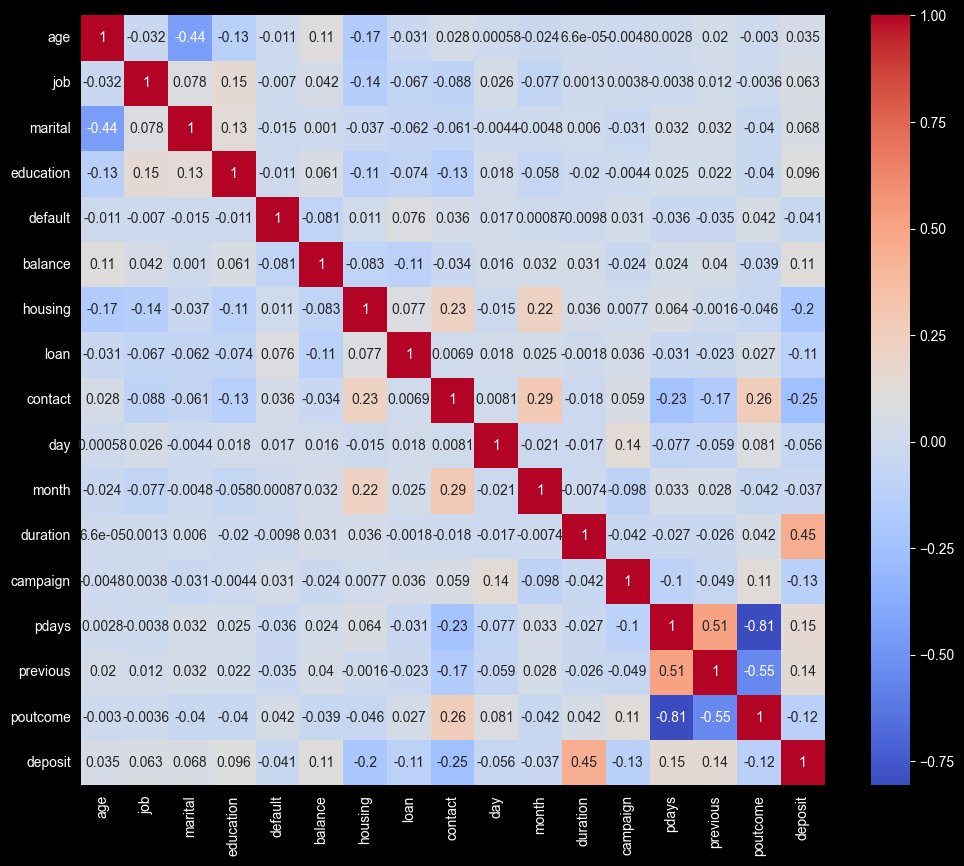

In [55]:
plt.figure(figsize=(12,10))
sns.heatmap(data_filter.corr(), annot=True, cmap="coolwarm")
plt.show()

In [56]:
tr=data_filter["deposit"]
fut=data_filter.drop("deposit",axis=1)
x_train,x_test,y_train,y_test=train_test_split(fut,tr,test_size=0.2,random_state=42)
y_train = y_train
y_test = y_test


In [57]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred=knn.predict(x_test)
accuracy_knn=round(accuracy_score(y_test,y_pred),2)
precesion_knn=round(precision_score(y_test,y_pred),2)
recall_knn=round(recall_score(y_test,y_pred),2)
f1_knn=around(f1_score(y_test,y_pred),2)
print("accurcy : {} \npercesion : {} \nrecall : {} \nf1 : {}".format(accuracy_knn,precesion_knn,recall_knn,f1_knn))

accurcy : 0.75 
percesion : 0.74 
recall : 0.72 
f1 : 0.73


In [58]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

log = LogisticRegression(max_iter=1000)
log.fit(x_train, y_train)
y_pred=log.predict(x_test)
accuracy_log=round(accuracy_score(y_test,y_pred),2)
precesion_log=round(precision_score(y_test,y_pred),2)
recall_log=round(recall_score(y_test,y_pred),2)
f1_log=around(f1_score(y_test,y_pred),2)
print("accurcy : {} \npercesion : {} \nrecall : {} \nf1 : {}".format(accuracy_log,precesion_log,recall_log,f1_log))

accurcy : 0.81 
percesion : 0.8 
recall : 0.79 
f1 : 0.79


In [59]:
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)
accurcy_dt=round(accuracy_score(y_test,y_pred),2)
precesion_dt=round(precision_score(y_test,y_pred),2)
recall_dt=round(recall_score(y_test,y_pred),2)
f1_dt=round(f1_score(y_test,y_pred),2)
print("accurcy : {} \npercesion : {} \nrecall : {} \nf1 : {}".format(accurcy_dt,precesion_dt,recall_dt,f1_dt))

accurcy : 0.78 
percesion : 0.78 
recall : 0.75 
f1 : 0.76


In [60]:
rf=RandomForestClassifier()
rf.fit(x_train, y_train)
y_pred=rf.predict(x_test)
accurcy_rf=round(accuracy_score(y_test,y_pred),2)
precesion_rf=round(precision_score(y_test,y_pred),2)
recall_rf=round(recall_score(y_test,y_pred),2)
f1_rf=round(f1_score(y_test,y_pred),2)
print("accurcy : {} \npercesion : {} \nrecall : {} \nf1 : {}".format(accurcy_rf,precesion_rf,recall_rf,f1_rf))

accurcy : 0.85 
percesion : 0.83 
recall : 0.87 
f1 : 0.85


In [61]:
gb=GradientBoostingClassifier()
gb.fit(x_train, y_train)
y_pred=gb.predict(x_test)
accurcy_gb=round(accuracy_score(y_test,y_pred),2)
precesion_gb=round(precision_score(y_test,y_pred),2)
recall_gb=round(recall_score(y_test,y_pred),2)
f1_gb=round(f1_score(y_test,y_pred),2)
print("accurcy : {} \npercesion : {} \nrecall : {} \nf1 : {}".format(accurcy_gb,precesion_gb,recall_gb,f1_gb))


accurcy : 0.86 
percesion : 0.83 
recall : 0.87 
f1 : 0.85


In [62]:
v=VotingClassifier(estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('lr', LogisticRegression(max_iter=1000)),
        ('dt', DecisionTreeClassifier()),
    ('rf', RandomForestClassifier()),
    ('gb', GradientBoostingClassifier()),
    ])
v.fit(x_train,y_train)
y_pred=v.predict(x_test)
accurcy_v=round(accuracy_score(y_test,y_pred),2)
precesion_v=round(precision_score(y_test,y_pred),2)
recall_v=round(recall_score(y_test,y_pred),2)
f1_v=round(f1_score(y_test,y_pred),2)
print("accurcy : {} \npercesion : {} \nrecall : {} \nf1 : {}".format(accurcy_v,precesion_v,recall_v,f1_v))


accurcy : 0.85 
percesion : 0.83 
recall : 0.86 
f1 : 0.85


In [63]:
dic={"Model name":["KNN","Logistic regretion","Desetion tree","Random forest","Gradient boosting","Voting"],
     "accurcy":[accuracy_knn,accuracy_log,accurcy_dt,accurcy_rf,accurcy_gb,accurcy_v],
     "precesion":[precesion_knn,precesion_log,precesion_dt,precesion_rf,precesion_gb,precesion_v],
     "recall":[recall_knn,recall_log,recall_dt,recall_rf,recall_gb,recall_v],
     'f1':[f1_knn,f1_log,f1_dt,f1_rf,f1_gb,f1_v]}
model=pd.DataFrame(dic)
model.sort_values(by='accurcy',ascending=False,inplace=True)
print(model)

           Model name  accurcy  precesion  recall    f1
4   Gradient boosting     0.86       0.83    0.87  0.85
3       Random forest     0.85       0.83    0.87  0.85
5              Voting     0.85       0.83    0.86  0.85
1  Logistic regretion     0.81       0.80    0.79  0.79
2       Desetion tree     0.78       0.78    0.75  0.76
0                 KNN     0.75       0.74    0.72  0.73


In [64]:
fig=px.bar(model,x="Model name",y="accurcy",color="Model name")
fig.show()

In [65]:
fig=px.bar(model,x="Model name",y="precesion",color="Model name")
fig.show()

In [66]:
fig=px.bar(model,x="Model name",y="recall",color="Model name")
fig.show()

In [71]:
scor = cross_val_score(gb,fut, tr, cv=20)
print(scor)
print("score : ",round(np.mean(scor)*100),"%")

[0.77297297 0.85045045 0.8954955  0.82342342 0.73873874 0.77297297
 0.79279279 0.81081081 0.74729242 0.78700361 0.8267148  0.83393502
 0.83212996 0.86823105 0.85740072 0.88086643 0.83754513 0.81768953
 0.83574007 0.8465704 ]
score :  82 %
